# Setup and Imports

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path

from tfmd.eeg import BCICompetitionIV2a
from tfmd.core import TFMD, TFMDOptions
from tfmd.utils import decompose_with_padding
from tfmd.visualization import plot_decomposition, plot_pipeline_steps, plot_spectrogram

# Prepare the Input

## Data Configuration

In [4]:
DATA_FILE = "../data/bcidatasetIV2a-raw-np/A01T.npz" 

if not Path(DATA_FILE).exists():
    print(f"WARNING: File {DATA_FILE} not found. Please update the path.")
else:
    print(f"Target dataset: {DATA_FILE}")

Target dataset: ../data/bcidatasetIV2a-raw-np/A01T.npz


## Load and Inspect Data

Creating RawArray with float64 data, n_channels=25, n_times=672528
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.
<Info | 8 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG, 3 EOG
 custom_ref_applied: False
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
>

Found 603 events.


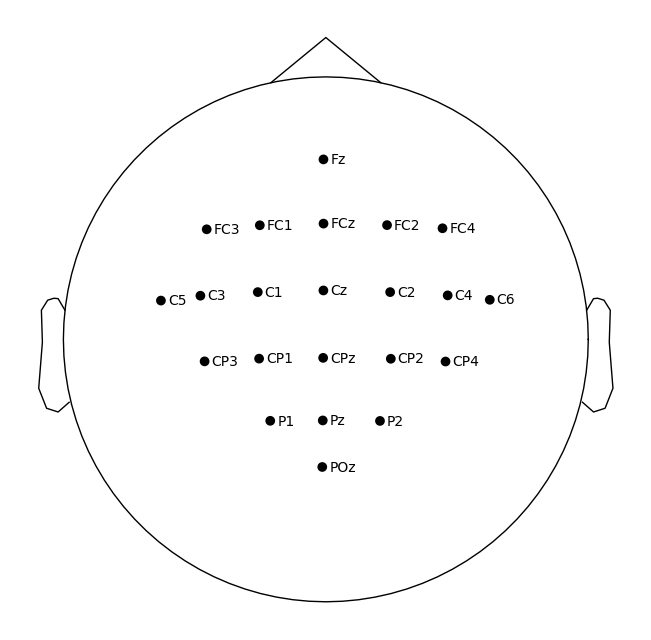

In [5]:
# 1. Load Data
loader = BCICompetitionIV2a(DATA_FILE)
raw, events = loader.load()

# 2. Inspect Metadata
print(raw.info)
print(f"\nFound {len(events)} events.")

# 3. Plot the raw sensor locations (Montage)
raw.plot_sensors(show_names=True)
plt.show()

## Preprocessing (Spectral Filtering)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/home/elahe/Projects/py/PyTFMD/.venv/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


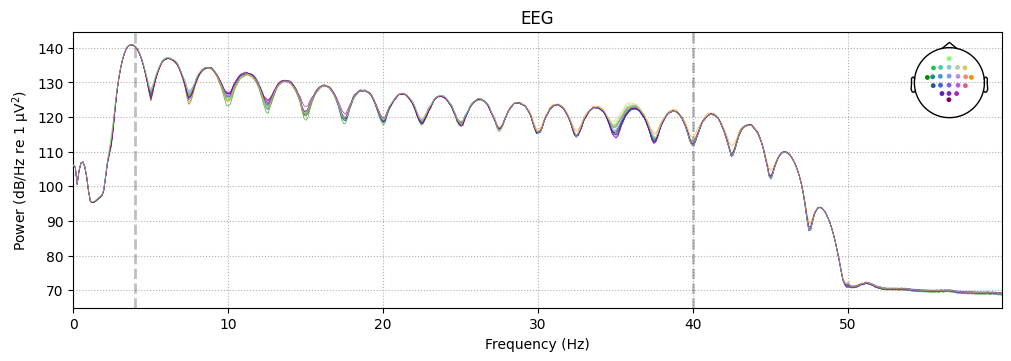

In [6]:
# Apply Bandpass Filter (4 - 40 Hz)
# - Low cut (4Hz): Removes DC offset and slow drift
# - High cut (40Hz): Removes mains hum (50Hz) and muscle noise
raw_filtered = raw.copy().filter(l_freq=4., h_freq=40., fir_design='firwin')

# Plot Power Spectral Density (PSD) to verify filtering
raw_filtered.plot_psd(fmax=60)
plt.show()

##  Epoching (Trial Extraction)

In [7]:
# Define Event IDs (from the loader class)
event_id = {'Left Hand': 769, 'Right Hand': 770}

# Create Epochs
# tmin, tmax: We take 0s to 4s relative to the cue
epochs = mne.Epochs(raw_filtered, events, event_id, tmin=0, tmax=4.0, 
                    baseline=None, preload=True)

print(epochs)

Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped
<Epochs | 144 events (all good), 0 – 4 s (baseline off), ~27.5 MiB, data loaded,
 'Left Hand': 72
 'Right Hand': 72>


## Select a Single Trial for Analysis

Analyzing: Trial 0, Channel C3
Signal Shape: (1001,), Sampling Rate: 250 Hz


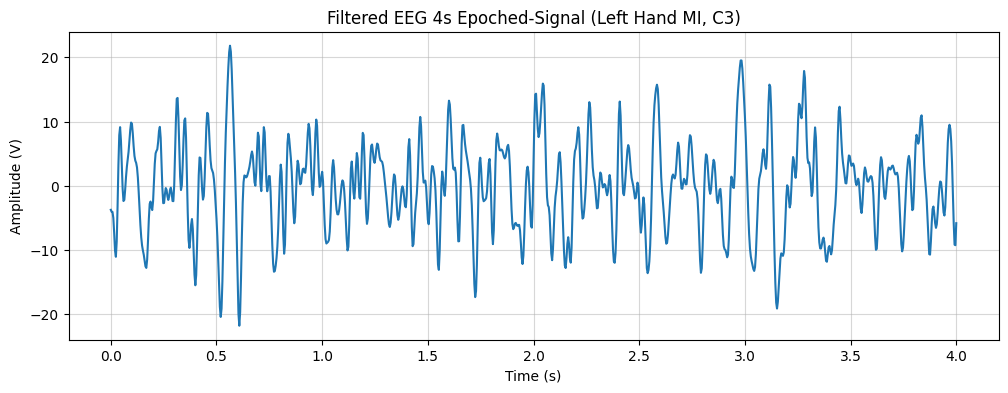

In [8]:
# Select a specific trial and channel
trial_idx = 0
channel_name = 'C3'

# Extract the signal as a 1D numpy array
# epochs.get_data() returns (n_epochs, n_channels, n_times)
signal = epochs['Left Hand'].get_data(copy=True)[trial_idx, epochs.ch_names.index(channel_name), :]
fs = int(epochs.info['sfreq'])
t = epochs.times

print(f"Analyzing: Trial {trial_idx}, Channel {channel_name}")
print(f"Signal Shape: {signal.shape}, Sampling Rate: {fs} Hz")

# Plot the time-domain signal
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title(f"Filtered EEG 4s Epoched-Signal (Left Hand MI, {channel_name})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.grid(True, alpha=0.5)
plt.show()

# Configure and Run TFMD

In [118]:
# 1. Configure TFMD
# Tuning for EEG (fs=250Hz):
# options = TFMDOptions(
#     window_length=64,   
#     alpha=2.5,          
#     overlap_ratio=0.9,
#     beta=0.4,           # Expansion factor
#     sigma=1e-3          # Min size threshold
# )
# options = TFMDOptions(
#     window_length=256,  # ~1.0 second. This is CRITICAL.
#     alpha=4.0,          # Higher alpha = narrower frequency bandwidth.->WRONG
#     overlap_ratio=0.95, # 95% overlap to create smooth horizontal continuity.
#     beta=0.6,
#     sigma=1e-2
# )
# options = TFMDOptions(
#     window_length=512,  # ~2.0 seconds. Aggressive frequency resolution.
#     alpha=1.0,          # LOW alpha = Wide Gaussian = Narrow Frequency bins.
#     overlap_ratio=0.95, # High overlap for smoothness.
#     beta=0.6,
#     sigma=1e-2
# )
# options = TFMDOptions(
#     window_length=256,  # Good balance
#     alpha=3.0,          # Standard shape (now correctly calculated)
#     overlap_ratio=0.9,  # Standard overlap
#     beta=0.4,
#     sigma=1e-2
# )
# options = TFMDOptions(
#     window_length=256,  # Good balance
#     alpha=1.5,          # Standard shape (now correctly calculated)
#     overlap_ratio=0.9,  # Standard overlap
#     beta=0.4,
#     sigma=1e-2
# ) # 2 modes detected but only one 
# options = TFMDOptions(
#     window_length=256,  # Keep this! We need ~1Hz resolution.
#     alpha=3.0,          # INCREASE this. Reduces smearing/leakage.
#     overlap_ratio=0.9,  # Standard is fine.
#     beta=0.4,           # Standard expansion.
#     sigma=1e-2          # Keep filtering small artifacts.
# )
options = TFMDOptions(
    window_length=256,  # ~2.0 seconds. Maximum frequency resolution.
    alpha=1.0,          # Wide window to sharpen frequency peaks.
    overlap_ratio=0.4,  # Standard overlap.
    beta=0.4,
    sigma=1e-3
)

decomposer = TFMD(options)

# 2. Decompose with Padding
# We use the utility function to handle edge effects
modes, reconstructed = decompose_with_padding(signal, fs, decomposer)

print(f"Decomposition complete. Found {len(modes)} modes.")

TFMD: Extracted 13 modes from signal (N=1257, fs=250 Hz)
Decomposition complete. Found 13 modes.


# Visualization (Time Domain)

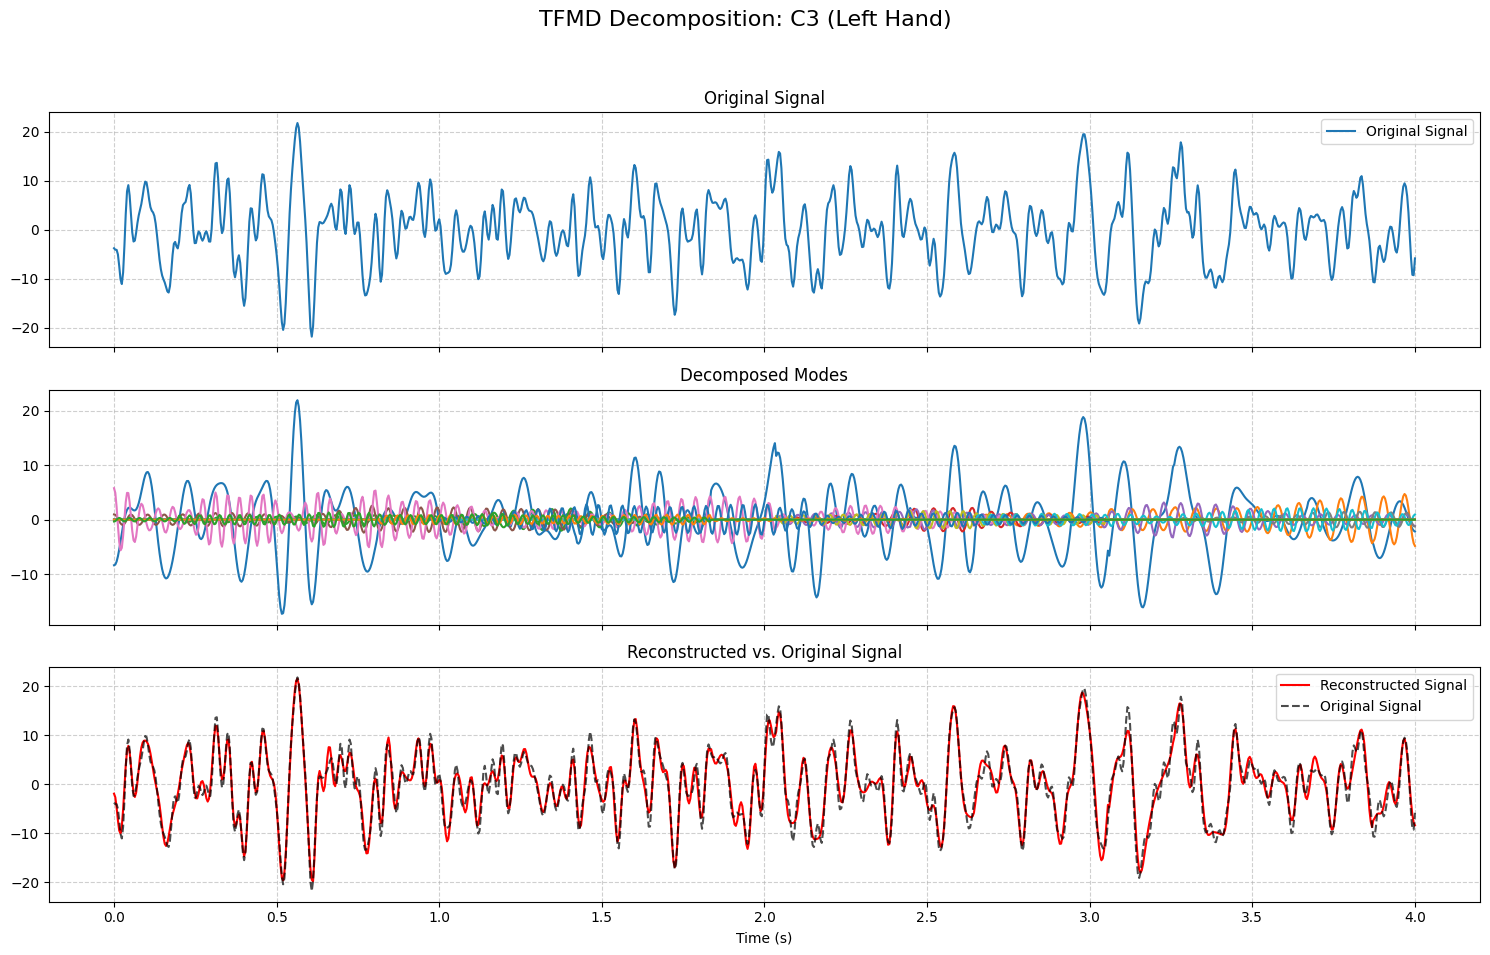

Relative L2 Error is 0.2200618168966572


In [119]:
plot_decomposition(
    original_signal=signal,
    t=t,
    modes=modes,
    reconstructed_signal=reconstructed,
    title=f"TFMD Decomposition: {channel_name} (Left Hand)",
    env='notebook'
)
error_tuned_2 = np.linalg.norm(signal - reconstructed) / np.linalg.norm(signal)
print(f"Relative L2 Error is {error_tuned_2}")

# inspecting intermediate results

TFMD: Extracted 16 modes from signal (N=1001, fs=250 Hz)


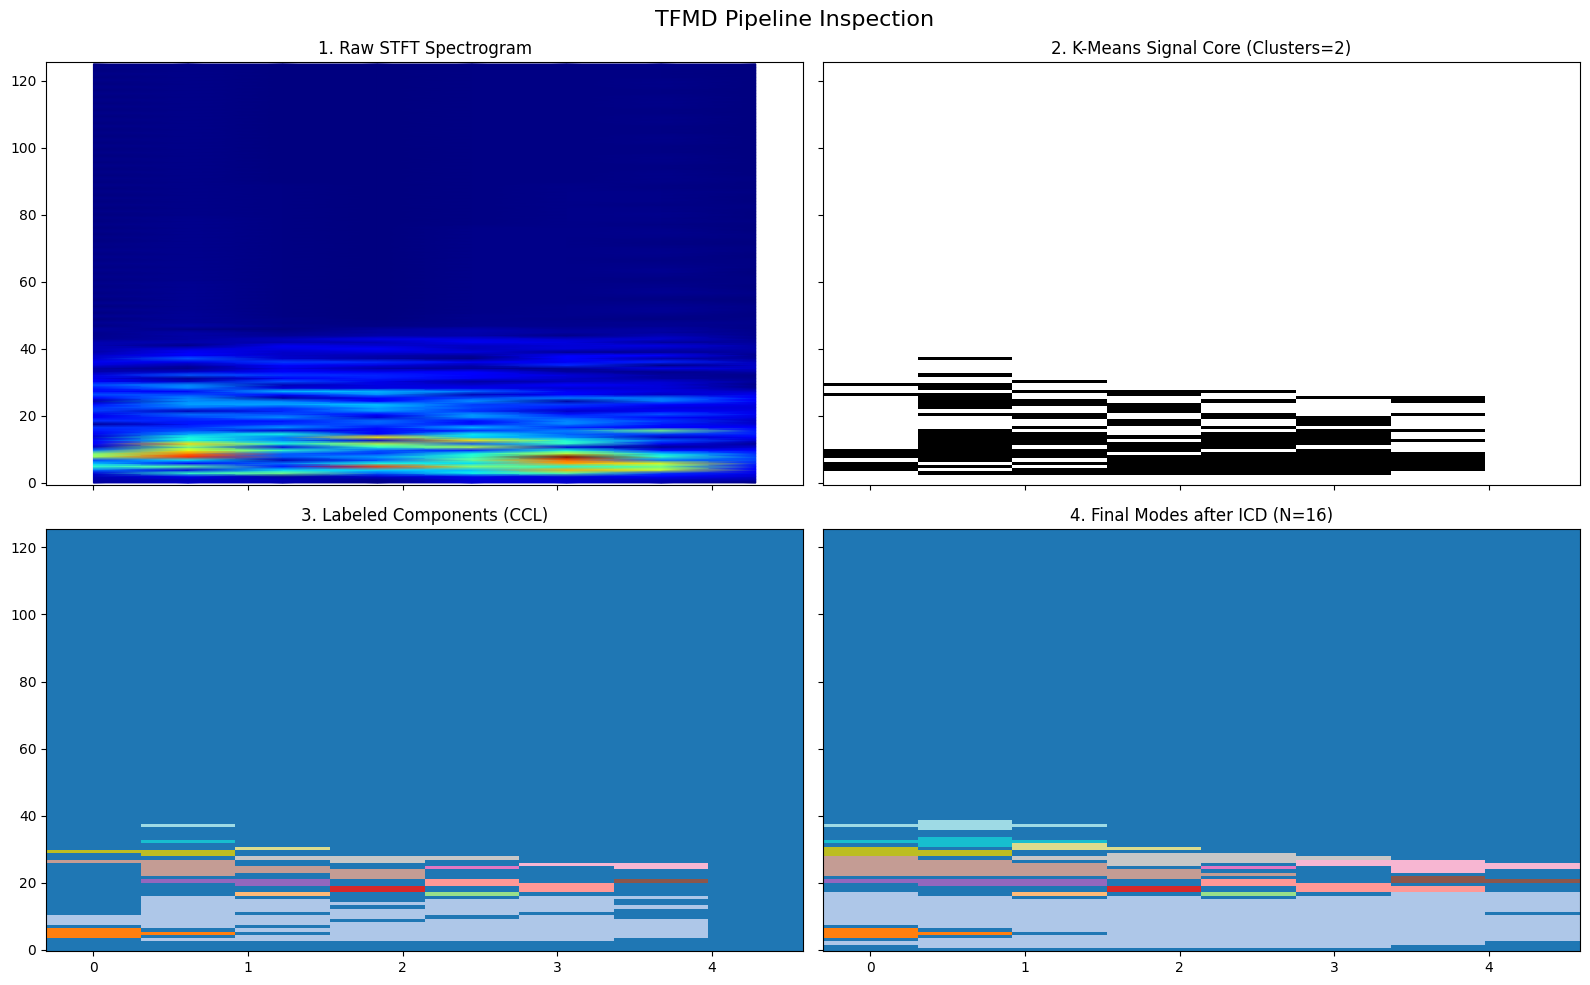

In [120]:
# We need to run the internal decompose again without padding to inspect the internal state objects
# (decompose_with_padding creates a new temporary instance or resets state)
# This is just for visualization purposes of the masks
decomposer.decompose(signal, fs) 

plot_pipeline_steps(decomposer, fs)

# Hypothesis Verification (Spectrogram Comparison)

We compare the spectrogram of the raw signal vs. the spectrogram of the "Dominant Mode" (usually Mode 1).
*   **Hypothesis:** The Mode 1 spectrogram should look "cleaner"—a distinct island of energy in the Mu/Alpha band—without the surrounding broadband noise.

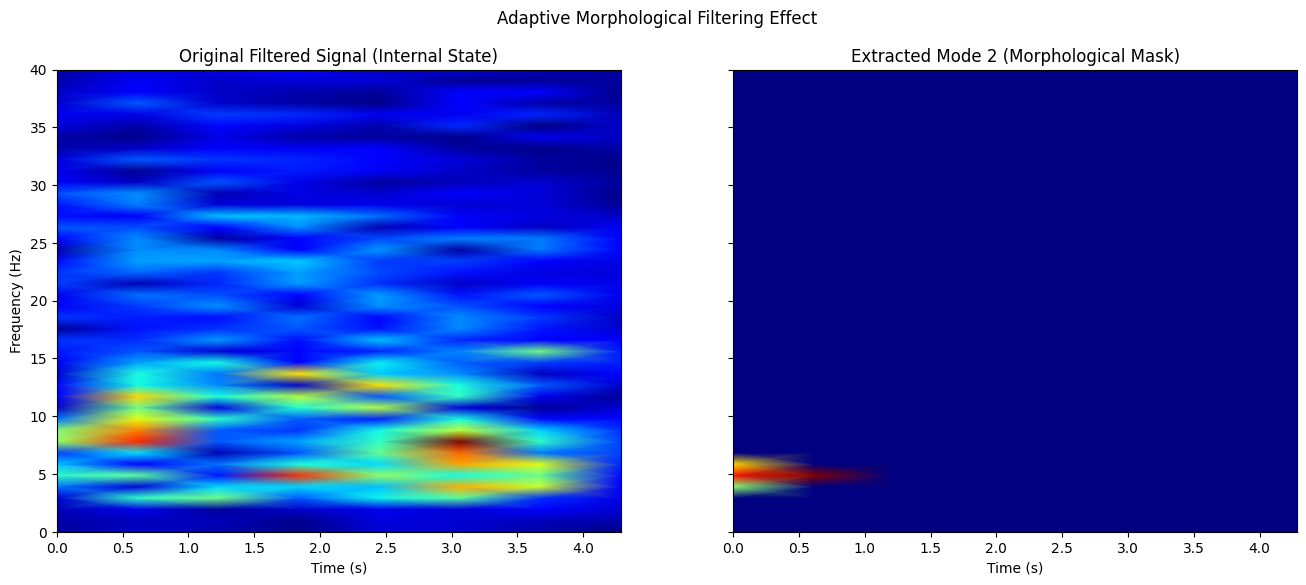

In [123]:
if len(modes) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # 1. Retrieve the exact data the algorithm used
    # S_raw is the magnitude spectrogram stored during the last .decompose() call
    S_raw = decomposer.spectrogram_
    
    # 2. Reconstruct the axes based on the stored shape
    # This ensures the time axis matches the trimmed signal exactly
    n_freqs, n_frames = S_raw.shape
    hop = int(options.window_length * (1 - options.overlap_ratio))
    
    f_axis = np.linspace(0, fs/2, n_freqs)
    t_spec = np.arange(n_frames) * hop / fs
    
    # 3. Plot Raw Signal Spectrogram (Left)
    # We use 'gouraud' shading to match the corrected pipeline visualization
    axes[0].pcolormesh(t_spec, f_axis, S_raw, shading='gouraud', cmap='jet')
    axes[0].set_title("Original Filtered Signal (Internal State)")
    axes[0].set_ylabel("Frequency (Hz)")
    axes[0].set_xlabel("Time (s)")
    
    # 4. Plot Mode 1 Spectrogram (Right)
    # Instead of re-calculating STFT, we visualize the MASKED energy.
    # This shows exactly which pixels TFMD selected to form Mode 1.
    # We use the first mask from the final_masks_ list.
    if decomposer.final_masks_:
        mask_mode_1 = decomposer.final_masks_[1]
        # Element-wise multiplication to show only the energy belonging to Mode 1
        S_mode_1 = S_raw * mask_mode_1
        
        axes[1].pcolormesh(t_spec, f_axis, S_mode_1, shading='gouraud', cmap='jet')
        axes[1].set_title("Extracted Mode 2 (Morphological Mask)")
        axes[1].set_xlabel("Time (s)")
    else:
        axes[1].text(0.5, 0.5, "No Mask Available", ha='center')

    # Focus on the relevant EEG bands (0-40 Hz)
    plt.ylim(0, 40) 
    plt.suptitle("Adaptive Morphological Filtering Effect")
    plt.show()
else:
    print("No modes found to compare.")